In [226]:
import pandas as pd
import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import RobustScaler  # better than StandardScaler for this data (outliers in BILL_AMT)
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, classification_report, 
                             ConfusionMatrixDisplay, RocCurveDisplay)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')


# Features details
- ID: ID of each client
- LIMIT_BAL: Amount of given credit in NT dollars (includes individual and family/supplementary credit
- SEX: Gender (1=male, 2=female)
- EDUCATION: (1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown)
- MARRIAGE: Marital status (1=married, 2=single, 3=others)
- AGE: Age in years
- PAY_0: Repayment status in September, 2005 (-1=pay duly, 1=payment delay for one month, 2=payment delay for two months, … 8=payment delay for eight months, 9=payment delay for nine months and above)
- PAY_2: Repayment status in August, 2005 (scale same as above)
- PAY_3: Repayment status in July, 2005 (scale same as above)
- PAY_4: Repayment status in June, 2005 (scale same as above)
- PAY_5: Repayment status in May, 2005 (scale same as above)
- PAY_6: Repayment status in April, 2005 (scale same as above)
- BILL_AMT1: Amount of bill statement in September, 2005 (NT dollar)
- BILL_AMT2: Amount of bill statement in August, 2005 (NT dollar)
- BILL_AMT3: Amount of bill statement in July, 2005 (NT dollar)
- BILL_AMT4: Amount of bill statement in June, 2005 (NT dollar)
- BILL_AMT5: Amount of bill statement in May, 2005 (NT dollar)
- BILL_AMT6: Amount of bill statement in April, 2005 (NT dollar)
- PAY_AMT1: Amount of previous payment in September, 2005 (NT dollar)
- PAY_AMT2: Amount of previous payment in August, 2005 (NT dollar)
- PAY_AMT3: Amount of previous payment in July, 2005 (NT dollar)
- PAY_AMT4: Amount of previous payment in June, 2005 (NT dollar)
- PAY_AMT5: Amount of previous payment in May, 2005 (NT dollar)
- PAY_AMT6: Amount of previous payment in April, 2005 (NT dollar)
- default.payment.next.month: Default payment (1=yes, 0=no)


In [219]:
dataset = pd.read_csv("dataset.csv")

dataset = dataset.drop(columns=["ID"])
dataset = dataset.rename(columns={"default.payment.next.month": "target"})
print(dataset.shape)
print(dataset.dtypes)
print(dataset["target"].value_counts(normalize=True))

(30000, 24)
LIMIT_BAL    float64
SEX            int64
EDUCATION      int64
MARRIAGE       int64
AGE            int64
PAY_0          int64
PAY_2          int64
PAY_3          int64
PAY_4          int64
PAY_5          int64
PAY_6          int64
BILL_AMT1    float64
BILL_AMT2    float64
BILL_AMT3    float64
BILL_AMT4    float64
BILL_AMT5    float64
BILL_AMT6    float64
PAY_AMT1     float64
PAY_AMT2     float64
PAY_AMT3     float64
PAY_AMT4     float64
PAY_AMT5     float64
PAY_AMT6     float64
target         int64
dtype: object
target
0    0.7788
1    0.2212
Name: proportion, dtype: float64


In [220]:
for i in dataset.columns.to_list():
    print(dataset[i].value_counts())

LIMIT_BAL
50000.0      3365
20000.0      1976
30000.0      1610
80000.0      1567
200000.0     1528
             ... 
730000.0        2
1000000.0       1
327680.0        1
760000.0        1
690000.0        1
Name: count, Length: 81, dtype: int64
SEX
2    18112
1    11888
Name: count, dtype: int64
EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64
MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64
AGE
29    1605
27    1477
28    1409
30    1395
26    1256
31    1217
25    1186
34    1162
32    1158
33    1146
24    1127
35    1113
36    1108
37    1041
39     954
38     944
23     931
40     870
41     824
42     794
44     700
43     670
45     617
46     570
22     560
47     501
48     466
49     452
50     411
51     340
53     325
52     304
54     247
55     209
56     178
57     122
58     122
59      83
60      67
21      67
61      56
62      44
63      31
64      31
66      25
65      24


In [232]:
dataset["EDUCATION"] = dataset["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
dataset["MARRIAGE"] = dataset["MARRIAGE"].replace({0: 3})
print(dataset["EDUCATION"].value_counts().sort_index())
print(dataset["MARRIAGE"].value_counts().sort_index())

EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64


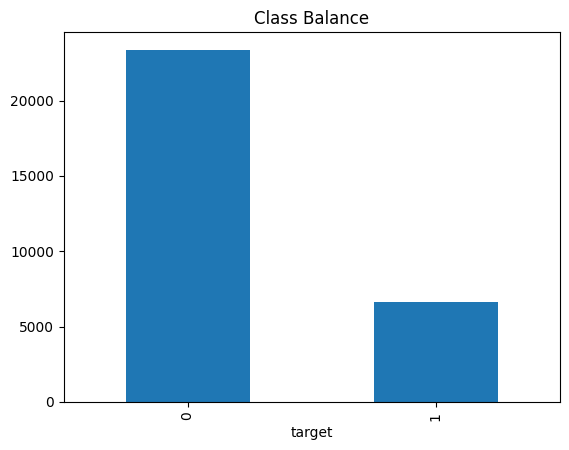

In [233]:
dataset["target"].value_counts().plot(kind="bar", title="Class Balance")
plt.show()



Default rate by EDUCATION:
EDUCATION
1    0.192348
2    0.237349
3    0.251576
4    0.070513
Name: target, dtype: float64

Default rate by MARRIAGE:
MARRIAGE
1    0.234717
2    0.209283
3    0.236074
Name: target, dtype: float64

Default rate by SEX:
SEX
1    0.241672
2    0.207763
Name: target, dtype: float64
target       1.000000
PAY_0        0.324794
PAY_2        0.263551
PAY_3        0.235253
PAY_4        0.216614
PAY_5        0.204149
PAY_6        0.186866
EDUCATION    0.033842
AGE          0.013890
BILL_AMT6   -0.005372
BILL_AMT5   -0.006760
BILL_AMT4   -0.010156
BILL_AMT3   -0.014076
BILL_AMT2   -0.014193
BILL_AMT1   -0.019644
MARRIAGE    -0.027575
SEX         -0.039961
PAY_AMT6    -0.053183
PAY_AMT5    -0.055124
PAY_AMT3    -0.056250
PAY_AMT4    -0.056827
PAY_AMT2    -0.058579
PAY_AMT1    -0.072929
LIMIT_BAL   -0.153520
Name: target, dtype: float64


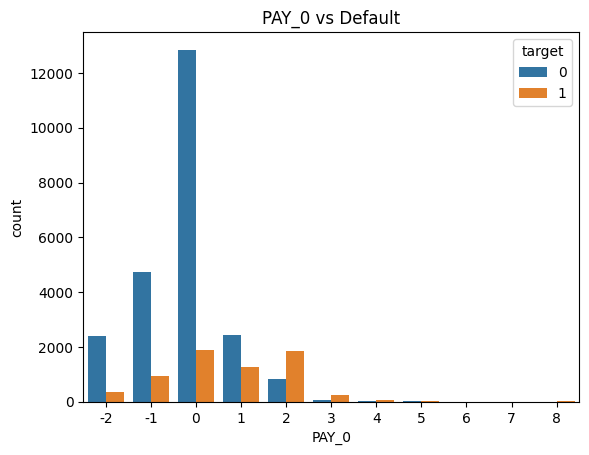

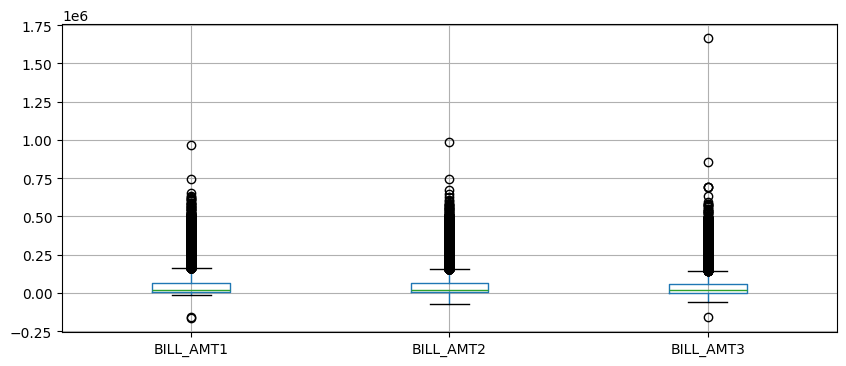

In [234]:
for col in ["EDUCATION", "MARRIAGE", "SEX"]:
    rate = dataset.groupby(col)["target"].mean()
    print(f"\nDefault rate by {col}:\n{rate}")

# 4c. Correlation with target
correlations = dataset.corr()["target"].sort_values(ascending=False)
print(correlations)

# 4d. Distribution of PAY_0 (most predictive feature in this dataset)
sns.countplot(x="PAY_0", hue="target", data=dataset)
plt.title("PAY_0 vs Default")
plt.show()

# 4e. Check for outliers in bill amounts
dataset[["BILL_AMT1","BILL_AMT2","BILL_AMT3"]].boxplot(figsize=(10,4))
plt.show()

In [235]:
# Average payment delay across all months
pay_cols = ["PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]
dataset["avg_pay_delay"] = dataset[pay_cols].mean(axis=1)

# Max delay (worst month behavior)
dataset["max_pay_delay"] = dataset[pay_cols].max(axis=1)

# How many months had a delay?
dataset["months_delayed"] = (dataset[pay_cols] > 0).sum(axis=1)

# Payment ratio: how much of the bill did they actually pay?
bill_cols = ["BILL_AMT1","BILL_AMT2","BILL_AMT3","BILL_AMT4","BILL_AMT5","BILL_AMT6"]
pay_amt_cols = ["PAY_AMT1","PAY_AMT2","PAY_AMT3","PAY_AMT4","PAY_AMT5","PAY_AMT6"]

total_bill = dataset[bill_cols].sum(axis=1).clip(lower=1)  # avoid div by zero
total_paid = dataset[pay_amt_cols].sum(axis=1)
dataset["payment_ratio"] = total_paid / total_bill

# Credit utilization
dataset["credit_util"] = dataset["BILL_AMT1"] / dataset["LIMIT_BAL"].clip(lower=1)

# Trend: is bill amount increasing? (bad sign)
dataset["bill_trend"] = dataset["BILL_AMT1"] - dataset["BILL_AMT6"]

In [237]:
X = dataset.drop(columns=["target"])
y = dataset["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,          # preserves class ratio in both splits
    random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train positive rate: {y_train.mean():.3f}")
print(f"Test positive rate:  {y_test.mean():.3f}")

Train: (24000, 29), Test: (6000, 29)
Train positive rate: 0.221
Test positive rate:  0.221


In [238]:
from imblearn.pipeline import Pipeline  # imblearn version supports samplers
from imblearn.over_sampling import SMOTE  # plain SMOTE since you've already fixed categoricals

# Define categorical feature indices for reference
cat_features = ["SEX", "EDUCATION", "MARRIAGE"]
cat_indices = [X_train.columns.get_loc(c) for c in cat_features]
print("Categorical indices:", cat_indices)

pipeline = Pipeline([
    ("scaler", RobustScaler()),
    ("smote", SMOTE(random_state=42)),           # SMOTE AFTER scaler is fine here
    ("clf", xgb.XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),  # handles imbalance natively
        random_state=42,
        eval_metric="auc",
        use_label_encoder=False
    ))
])

Categorical indices: [1, 2, 3]


In [240]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    pipeline, X_train, y_train,
    cv=cv,
    scoring=["roc_auc", "f1", "precision", "recall"],
    return_train_score=True,
    n_jobs=-1
)

for metric in ["roc_auc", "f1", "precision", "recall"]:
    val = cv_results[f"test_{metric}"]
    print(f"{metric:12s}: {val.mean():.4f} ± {val.std():.4f}")

roc_auc     : 0.7745 ± 0.0064
f1          : 0.4836 ± 0.0060
precision   : 0.3498 ± 0.0056
recall      : 0.7830 ± 0.0080


In [241]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "clf__n_estimators": [100, 200, 300],
    "clf__max_depth": [3, 4, 5, 6],
    "clf__learning_rate": [0.01, 0.05, 0.1],
    "clf__subsample": [0.7, 0.8, 0.9],
    "clf__colsample_bytree": [0.7, 0.8, 0.9],
    "clf__min_child_weight": [1, 3, 5]
}

search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_grid,
    n_iter=30,              # try 30 random combos
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(X_train, y_train)
print("Best params:", search.best_params_)
print("Best CV AUC:", search.best_score_)

best_model = search.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'clf__subsample': 0.7, 'clf__n_estimators': 200, 'clf__min_child_weight': 3, 'clf__max_depth': 5, 'clf__learning_rate': 0.01, 'clf__colsample_bytree': 0.9}
Best CV AUC: 0.7804388554269159


In [242]:
from sklearn.metrics import precision_recall_curve

y_proba = best_model.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

# Find threshold that maximizes F1
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_thresh = thresholds[f1_scores[:-1].argmax()]
print(f"Best F1 threshold: {best_thresh:.4f}")

# Or if recall matters more (catching defaults is more important than false alarms):
# pick threshold where recall >= 0.85
high_recall_thresh = thresholds[recalls[:-1] >= 0.85][0]
print(f"High-recall threshold: {high_recall_thresh:.4f}")

Best F1 threshold: 0.7574
High-recall threshold: 0.2197


ROC-AUC: 0.7728
              precision    recall  f1-score   support

           0       0.87      0.84      0.86      4673
           1       0.50      0.57      0.53      1327

    accuracy                           0.78      6000
   macro avg       0.69      0.71      0.70      6000
weighted avg       0.79      0.78      0.78      6000



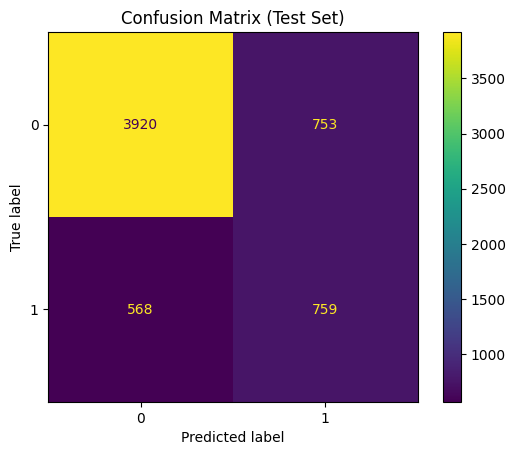

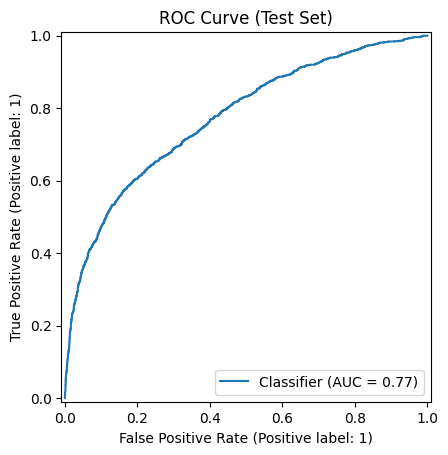

In [243]:
y_pred = (y_proba >= best_thresh).astype(int)

print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(classification_report(y_test, y_pred))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix (Test Set)")
plt.show()

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve (Test Set)")
plt.show()

ROC-AUC: 0.7728
              precision    recall  f1-score   support

           0       0.87      0.84      0.86      4673
           1       0.50      0.57      0.53      1327

    accuracy                           0.78      6000
   macro avg       0.69      0.71      0.70      6000
weighted avg       0.79      0.78      0.78      6000



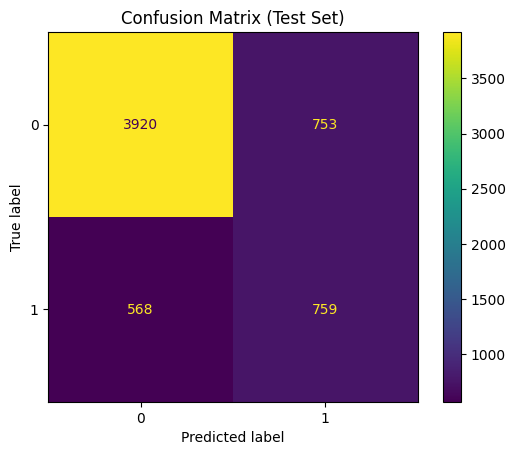

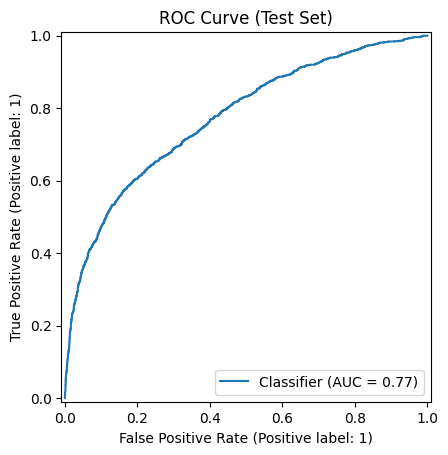

In [244]:
y_pred = (y_proba >= best_thresh).astype(int)

print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(classification_report(y_test, y_pred))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix (Test Set)")
plt.show()

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve (Test Set)")
plt.show()

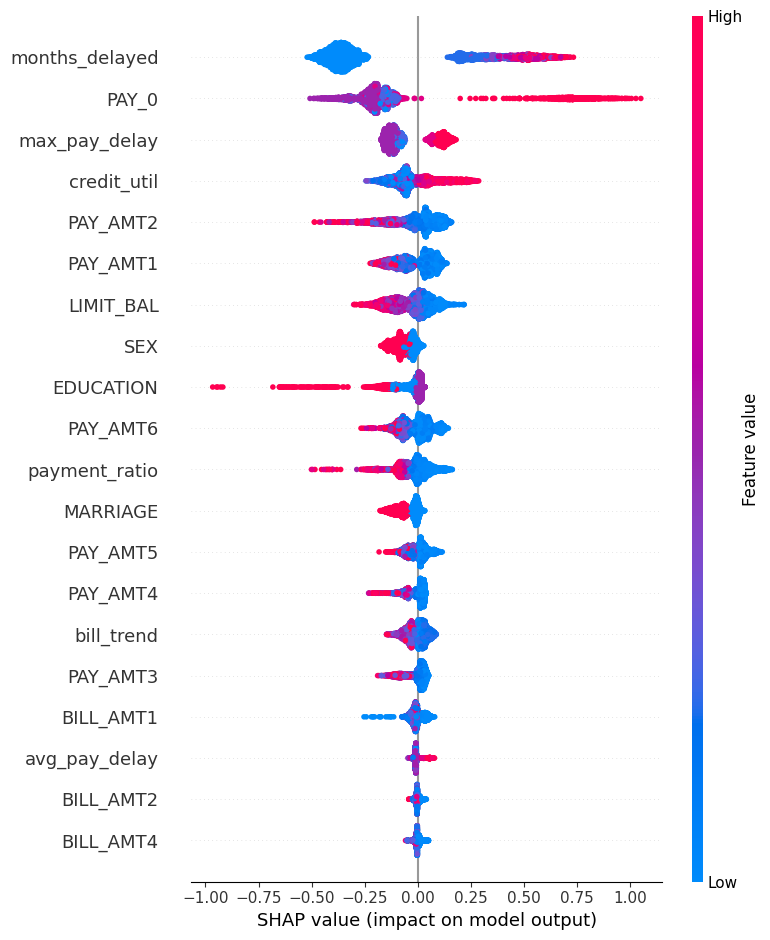

In [248]:
import shap

xgb_model = best_model.named_steps["clf"]

# Manually apply each non-classifier step in order
X_test_scaled = best_model.named_steps["scaler"].transform(X_test)
# Skip smote — it's only for training, not inference
X_test_transformed = X_test_scaled

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transformed)

shap.summary_plot(shap_values, X_test_transformed, feature_names=X_test.columns.tolist())